In [1]:
# epoch影响较大
%run stage1.py \
    --sc_file "/mnt/d/ST_Graduation_Project/database/Wu/CID44971/CID44971_SC.h5ad" \
    --st_file "/mnt/d/ST_Graduation_Project/database/Wu/CID44971/CID44971_ST.h5ad" \
    --n_epochs 500 \
    --resolution 2 \
    --loss_type zinb \
    --beta 0.1 \
    --lambda_mmd 1.0 \
    --top_n_per_type  100 \
    --latent_dim 256 \
    --output_dir ./stage1_results/CID44971
 #   --precomputed_marker_file "/mnt/d/ST_Graduation_Project/SC_MAP_ST/stage1_results/CID44971/final_genes.txt"

/home/mwc/miniconda3/envs/dl/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu
Stage 1 Training: VAE (SC + ST, Marker Genes)
Configuration:
   Marker genes per type: 100
   Leiden resolution: 2.0
   Batch size: 256
   Epochs: 500
   Learning rate: 0.001
   Beta (KL weight): 0.1
   Hidden dims: [512, 256]
   Latent dim: 256
   Loss type: ZINB
   Lambda MMD: 1.0
   Dual Decoder: True
Loading datasets...
   Loading SC: /mnt/d/ST_Graduation_Project/database/Wu/CID44971/CID44971_SC.h5ad
   SC shape: (7986, 29733)
   SC shape: (7986, 29733)
   SC avg counts/cell: 6629.2 (from X)
   Loading ST: /mnt/d/ST_Graduation_Project/database/Wu/CID44971/CID44971_ST.h5ad
   SC avg counts/cell: 6629.2 (from X)
   Loading ST: /mnt/d/ST_Graduation_Project/database/Wu/CID44971/CID44971_ST.h5ad
   ST shape: (1147, 23531)
   Common genes: 17415
   SC final: (7986, 17415)
   ST final: (1147, 17415)
Computing clusters and marker genes...
Starting clustering analysis...
   ST shape: (1147, 23531)
   Common genes: 17415
   SC final: (7986, 17415)
   ST final: (1147, 17415)

KeyboardInterrupt: 

---

Sample name: CID44971
Stage 1 model: ./stage1_results/CID44971/final_vae.pth
Output directory: ./stage2_results/CID44971/
Device: cpu
Weight threshold: 0.01
Loading pretrained VAE Encoder...
   VAE architecture: 874 -> 256
   Output type: zinb
   Architecture: Dual Decoder (SC/ST-specific)
   ✓ Loaded 7980 cell cluster labels from checkpoint
Loaded cluster centers: torch.Size([49, 256])
Loaded cluster expressions: torch.Size([49, 874])
Loaded avg_cell_counts: 6629.2 (for scale factor calculation)
Loaded full gene expressions (count): 49 clusters × 17415 genes
Loaded all genes list: 17415 genes
VAE Encoder loaded: 874 -> 256
Cell type clusters: ['0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '4', '40', '41', '42', '43', '44', '45', '46', '47', '48', '5', '6', '7', '8', '9']
Marker genes: 874
Using Stage 1 cluster centers and expressions

GAT Training:  65%|██████▌   | 196/300 [07:22<03:54,  2.26s/epoch, Total=407.9495, Pearson=0.2259, MSE=407.4487, Cosine=0.1252, Proportion=1.4590]



Evaluating model results...
Cells per spot: 1.9611555337905884
Applying weight threshold: 0.01
   Non-zero elements: 22940 -> 9879 (17.6%)
Saving deconvolution results...
Generating deconvolution expression matrices...
   Marker gene expression...
Applying weight threshold: 0.01
   Non-zero elements: 22940 -> 9879 (17.6%)
Saving deconvolution results...
Generating deconvolution expression matrices...
   Marker gene expression...
   Full gene expression...
   Full gene expression...
   Cell type composition...
   Cell type composition...
   Found duplicate celltype names: ['Myeloid', 'CAFs', 'Cancer Epithelial', 'T-cells', 'Normal Epithelial', 'Endothelial', 'B-cells']. Merging corresponding cluster columns by summing weights.
   Columns before: 49, after merge: 9
   Saved cell composition (celltype): ./stage2_results/CID44971//CID44971_cell_composition.csv
   Saved cluster composition: ./stage2_results/CID44971//CID44971_cluster_composition.csv

Computing reconstruction quality per spo

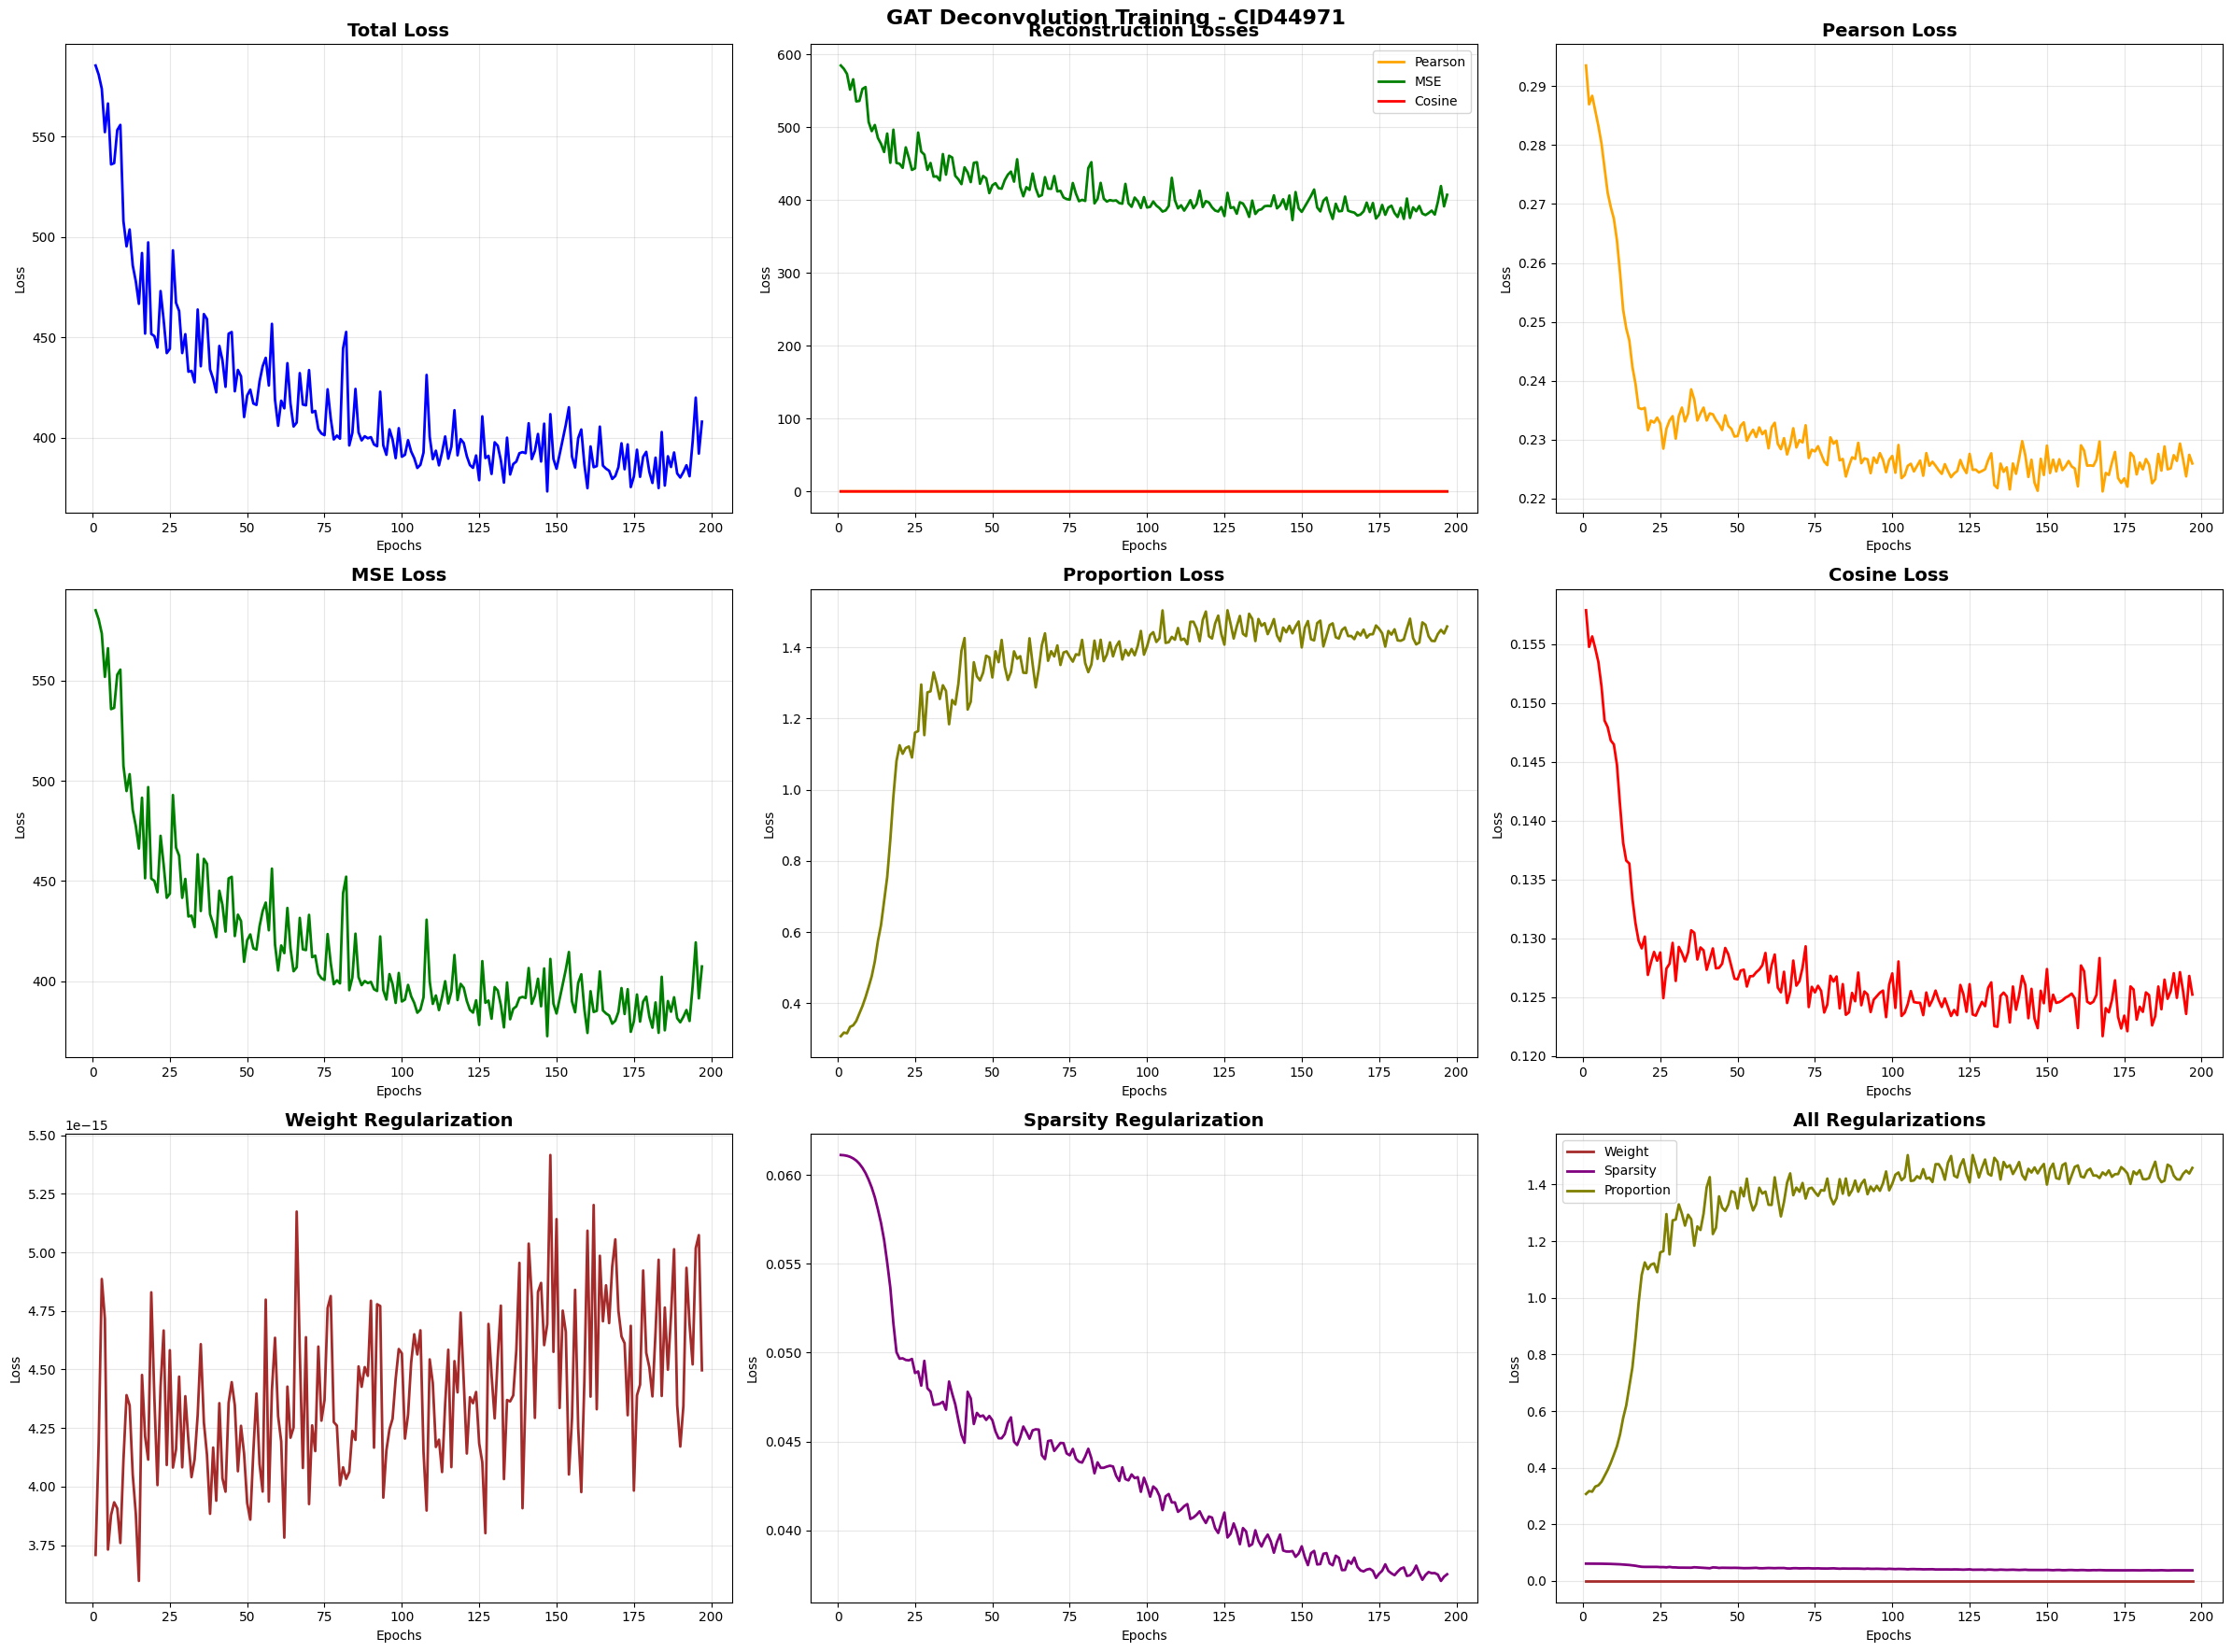

In [10]:
# λ 越大更稀疏0.1-0.5
%run stage2.py \
    --st_file "/mnt/d/ST_Graduation_Project/database/Wu/CID44971/CID44971_ST.h5ad" \
    --stage1_model_path "./stage1_results/CID44971/final_vae.pth" \
    --output_dir "./stage2_results/CID44971/" \
    --gat_hidden_dim 512 \
    --gat_layers 4 \
    --lr 1e-4 \
    --loss_lambda_mse 1 \
    --loss_lambda_cosine 1 \
    --loss_lambda_pearson 1 \
    --loss_lambda_reg 0.1 \
    --loss_lambda_sparse 0.1 \
    --loss_lambda_proportion 0.1 \
    --k_spatial 10 \
    --k_celltype 20 \
    --batch_size 512 \
    --n_epochs 300 \
    --weight_threshold 0.01